## Traffic Volume Prediction System
###### The objective of this project is to predict traffic volume using historical traffic data and environmental features such as time and weather conditions.

### Import libraries

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
df

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
...,...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450


In [68]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [70]:
df.isna().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

### Handling Missing Values

In [71]:
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume'],
      dtype='object')

In [72]:
df['holiday'] = df['holiday'].fillna('No_Holiday')
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,No_Holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,No_Holiday,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,No_Holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,No_Holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,No_Holiday,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


### Convert Date column from object to datetime format

In [73]:
df['date_time'] = pd.to_datetime(df['date_time'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              48204 non-null  object        
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  object        
 6   weather_description  48204 non-null  object        
 7   date_time            48204 non-null  datetime64[ns]
 8   traffic_volume       48204 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 3.3+ MB


In [74]:
df['Hour'] = df['date_time'].dt.hour
df['Year'] = df['date_time'].dt.year
df['Months'] = df['date_time'].dt.month
df['day'] = df['date_time'].dt.day
df['weekday'] = df['date_time'].dt.weekday

In [75]:
df.drop('date_time', axis = 1, inplace = True)

In [76]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume,Hour,Year,Months,day,weekday
0,No_Holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,5545,9,2012,10,2,1
1,No_Holiday,289.36,0.0,0.0,75,Clouds,broken clouds,4516,10,2012,10,2,1
2,No_Holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,4767,11,2012,10,2,1
3,No_Holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,5026,12,2012,10,2,1
4,No_Holiday,291.14,0.0,0.0,75,Clouds,broken clouds,4918,13,2012,10,2,1


### Drop the column weather_description

In [77]:
df.drop( columns = ['weather_description'] , axis = 1, inplace = True)
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,traffic_volume,Hour,Year,Months,day,weekday
0,No_Holiday,288.28,0.0,0.0,40,Clouds,5545,9,2012,10,2,1
1,No_Holiday,289.36,0.0,0.0,75,Clouds,4516,10,2012,10,2,1
2,No_Holiday,289.58,0.0,0.0,90,Clouds,4767,11,2012,10,2,1
3,No_Holiday,290.13,0.0,0.0,90,Clouds,5026,12,2012,10,2,1
4,No_Holiday,291.14,0.0,0.0,75,Clouds,4918,13,2012,10,2,1


#### Distribution of Traffic volume

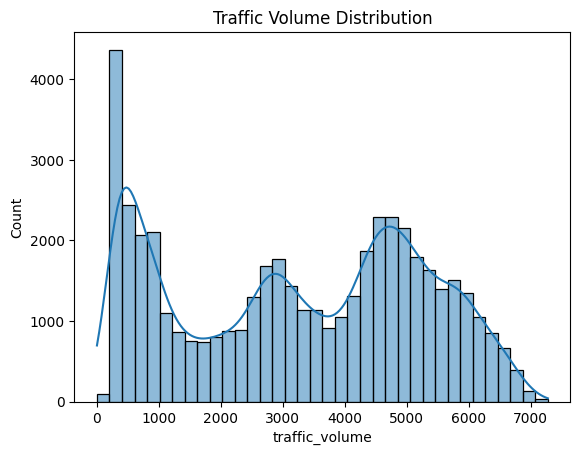

In [78]:
sns.histplot(df['traffic_volume'], kde = True)
plt.title('Traffic Volume Distribution')
plt.show()

##### Traffic volume shows variability with peak clustering around high-density hours.

#### Traffic by Hour 

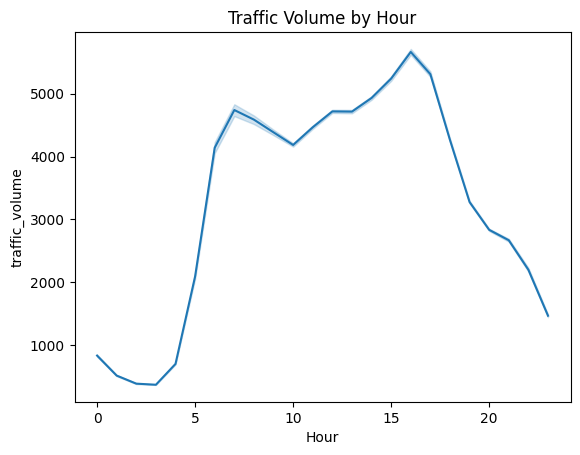

In [79]:
sns.lineplot(x='Hour', y='traffic_volume', data=df)
plt.title("Traffic Volume by Hour")
plt.show()

##### Clear peak patterns are observed during morning and evening rush hours.

#### Traffic by Day of Week

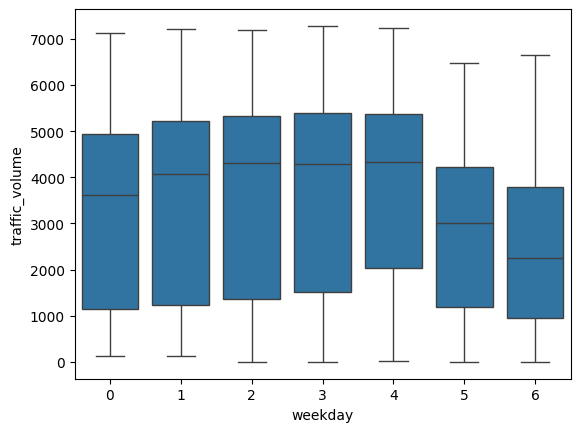

In [80]:
sns.boxplot(x='weekday', y='traffic_volume', data=df)
plt.show()

##### Weekdays exhibit higher median traffic compared to weekends.

#### Traffic vs Weather

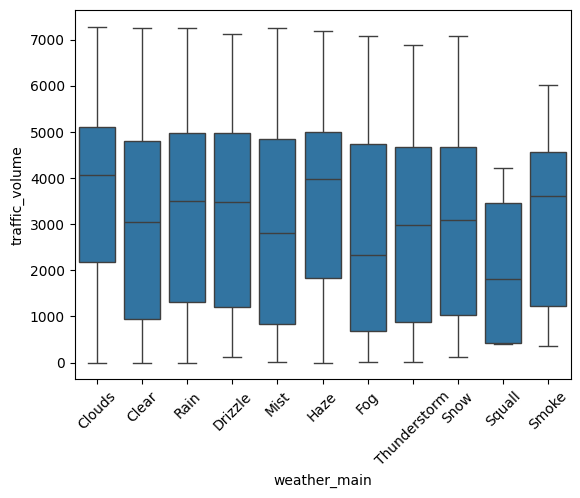

In [81]:
sns.boxplot(x='weather_main', y='traffic_volume', data=df)
plt.xticks(rotation=45)
plt.show()

##### Weather conditions influence traffic variation

### Correlation Heatmap

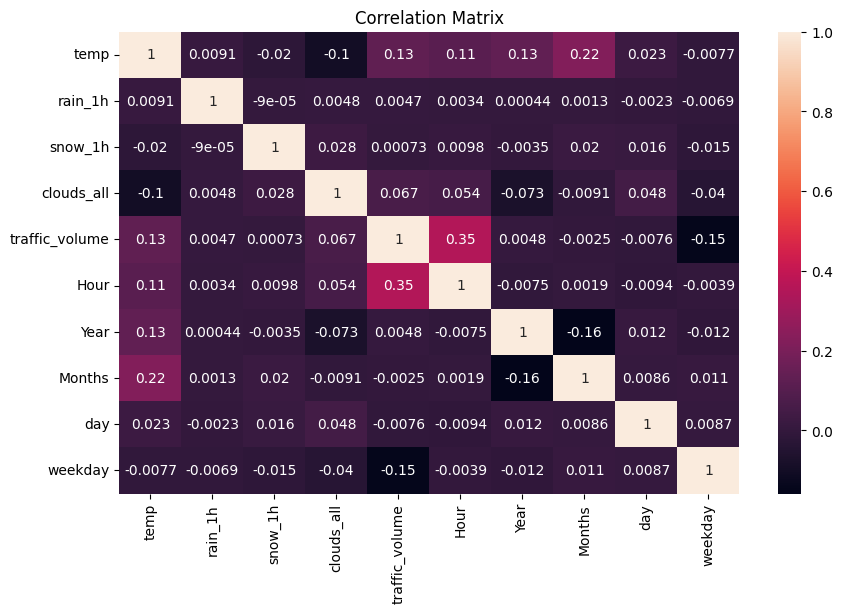

In [82]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

###  categorical variables into numerical by OneHotEncoding

In [83]:
newdf = pd.get_dummies(df, columns = ['holiday','weather_main'], drop_first = True)
newdf

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,Hour,Year,Months,day,weekday,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,288.28,0.0,0.0,40,5545,9,2012,10,2,1,...,True,False,False,False,False,False,False,False,False,False
1,289.36,0.0,0.0,75,4516,10,2012,10,2,1,...,True,False,False,False,False,False,False,False,False,False
2,289.58,0.0,0.0,90,4767,11,2012,10,2,1,...,True,False,False,False,False,False,False,False,False,False
3,290.13,0.0,0.0,90,5026,12,2012,10,2,1,...,True,False,False,False,False,False,False,False,False,False
4,291.14,0.0,0.0,75,4918,13,2012,10,2,1,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48199,283.45,0.0,0.0,75,3543,19,2018,9,30,6,...,True,False,False,False,False,False,False,False,False,False
48200,282.76,0.0,0.0,90,2781,20,2018,9,30,6,...,True,False,False,False,False,False,False,False,False,False
48201,282.73,0.0,0.0,90,2159,21,2018,9,30,6,...,False,False,False,False,False,False,False,False,False,True
48202,282.09,0.0,0.0,90,1450,22,2018,9,30,6,...,True,False,False,False,False,False,False,False,False,False


In [84]:
bool_cols = newdf.select_dtypes(bool).columns
newdf[bool_cols] = newdf[bool_cols].astype(int)

In [85]:
newdf.dtypes

temp                                 float64
rain_1h                              float64
snow_1h                              float64
clouds_all                             int64
traffic_volume                         int64
Hour                                   int32
Year                                   int32
Months                                 int32
day                                    int32
weekday                                int32
holiday_Columbus Day                   int64
holiday_Independence Day               int64
holiday_Labor Day                      int64
holiday_Martin Luther King Jr Day      int64
holiday_Memorial Day                   int64
holiday_New Years Day                  int64
holiday_No_Holiday                     int64
holiday_State Fair                     int64
holiday_Thanksgiving Day               int64
holiday_Veterans Day                   int64
holiday_Washingtons Birthday           int64
weather_main_Clouds                    int64
weather_ma

### Assign X, y variables

In [86]:
X = newdf.drop(columns = ['traffic_volume'])
y = newdf['traffic_volume']

### Standardise the data using Standard Scaler

In [87]:
from sklearn.preprocessing import StandardScaler

In [88]:
scaler = StandardScaler()

In [89]:
xcolumns = X.columns.tolist()

In [90]:
X = scaler.fit_transform(X)

In [91]:
X = pd.DataFrame(X, columns = xcolumns)
X.head()

,temp,rain_1h,snow_1h,clouds_all,Hour,Year,Months,day,weekday,holiday_Columbus Day,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,0.530370,-0.007463,-0.027228,-0.239963,-0.345548,-1.855294,1.02758,-1.574903,-0.989561,-0.010185,...,1.476091,-0.198142,-0.138868,-0.170389,-0.375253,-0.365183,-0.020373,-0.25189,-0.00911,-0.148056
1,0.611341,-0.007463,-0.027228,0.657120,-0.201459,-1.855294,1.02758,-1.574903,-0.989561,-0.010185,...,1.476091,-0.198142,-0.138868,-0.170389,-0.375253,-0.365183,-0.020373,-0.25189,-0.00911,-0.148056
2,0.627836,-0.007463,-0.027228,1.041584,-0.057371,-1.855294,1.02758,-1.574903,-0.989561,-0.010185,...,1.476091,-0.198142,-0.138868,-0.170389,-0.375253,-0.365183,-0.020373,-0.25189,-0.00911,-0.148056
3,0.669071,-0.007463,-0.027228,1.041584,0.086718,-1.855294,1.02758,-1.574903,-0.989561,-0.010185,...,1.476091,-0.198142,-0.138868,-0.170389,-0.375253,-0.365183,-0.020373,-0.25189,-0.00911,-0.148056
4,0.744794,-0.007463,-0.027228,0.657120,0.230807,-1.855294,1.02758,-1.574903,-0.989561,-0.010185,...,1.476091,-0.198142,-0.138868,-0.170389,-0.375253,-0.365183,-0.020373,-0.25189,-0.00911,-0.148056


In [92]:
y.shape

(48204,)

In [93]:
X.shape

(48204, 30)

### Split the data into training and testing set

In [94]:
from sklearn.model_selection import train_test_split

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 100)

In [96]:
X_train.size

1012260

In [97]:
X_test.size

433860

### Linear Regression Model

In [98]:
from sklearn.linear_model import LinearRegression

In [99]:
model_lr = LinearRegression()

In [100]:
model_lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [101]:
model_lr.score(X_train, y_train)

0.16507857621247912

In [102]:
coeff = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model_lr.coef_
})

coeff.sort_values(by="Coefficient", ascending=False)    # negative-- traffic decreases

,Feature,Coefficient
4,Hour,652.976310
0,temp,197.161825
20,weather_main_Clouds,121.418696
3,clouds_all,92.796845
23,weather_main_Haze,52.135876
15,holiday_No_Holiday,45.269138
14,holiday_New Years Day,3.558957
5,Year,2.221036
17,holiday_Thanksgiving Day,0.830050
28,weather_main_Squall,0.000000


In [103]:
y_pred_lr = model_lr.predict(X_test)

### Evaluate the model

In [104]:
from sklearn import metrics
from sklearn.metrics import mean_absolute_error

In [105]:
metrics.mean_squared_error(y_test,y_pred_lr)

9743565.617832456

In [106]:
metrics.r2_score(y_test, y_pred_lr)

-1.462079691159634

In [107]:
mean_absolute_error(y_test,y_pred_lr)

1609.2302046438879

### Plot Actual vs Predict

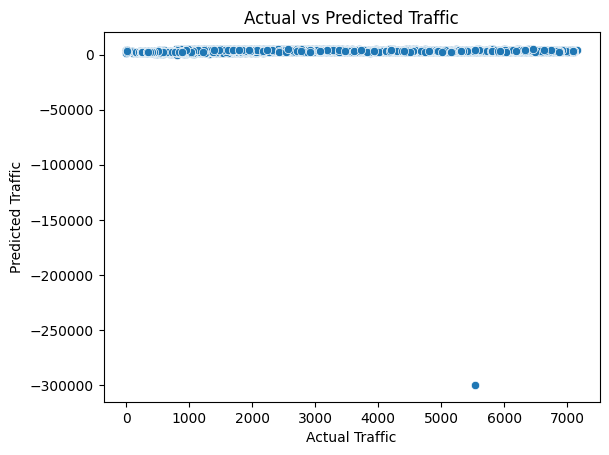

In [108]:
sns.scatterplot(x = y_test, y = y_pred_lr)
plt.xlabel('Actual Traffic')
plt.ylabel('Predicted Traffic')
plt.title('Actual vs Predicted Traffic')
plt.show()

### Random Forest

In [109]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [110]:
grid_rf = GridSearchCV(estimator=RandomForestRegressor(random_state = 42),
             param_grid={'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]},
             cv=3,
    scoring="r2",
    n_jobs=-1)

In [111]:
grid_rf.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [112]:
grid_rf.best_params_

{'max_depth': 20,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [113]:
best_rf = grid_rf.best_estimator_          # tuned model
best_rf

,n_estimators,100
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [114]:
grid_rf.best_score_

np.float64(0.9582043153692709)

In [117]:
model_rf = RandomForestRegressor(max_depth = 15,
 min_samples_leaf= 2,
 min_samples_split= 5,
 n_estimators= 80,
random_state=42
)

In [118]:
model_rf.fit(X_train,y_train)

,n_estimators,80
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [119]:
model_rf.score(X_train,y_train)

0.9822188912139335

In [120]:
y_pred_rf = model_rf.predict(X_test)

In [121]:
# predict with optimized model
y_pred_best = best_rf.predict(X_test)

### Evaluate the model

In [122]:
metrics.mean_squared_error(y_test,y_pred_best)

139568.50545737694

In [123]:
metrics.r2_score(y_test, y_pred_best)

0.9647327481242381

In [124]:
mean_absolute_error(y_test,y_pred_best)

207.7214849317452

### Plot Actual vs Predict

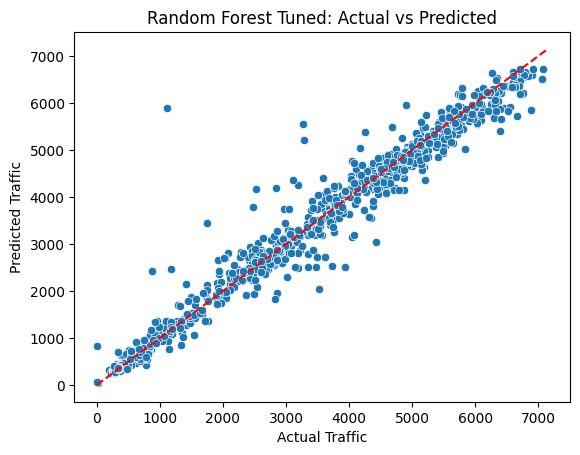

In [125]:
sns.scatterplot(x=y_test.values[:1000], y=y_pred_best[:1000])  # for large data
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel('Actual Traffic')
plt.ylabel('Predicted Traffic')
plt.title('Random Forest Tuned: Actual vs Predicted')
plt.show()

### Residual Plot

If prediction is perfect → residual = 0

If residual is positive → model under-predicted

If residual is negative → model over-predicted

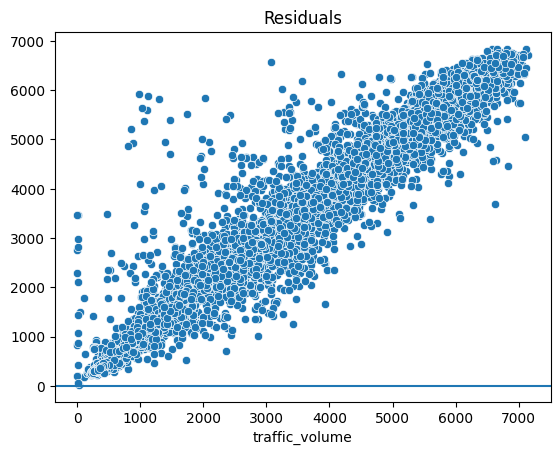

In [126]:
residuals = y_test - y_pred_best
sns.scatterplot( x = y_test, y = y_pred_best)
plt.axhline(0)
plt.title('Residuals')
plt.show()

### Feature Importance

In [127]:
importance_df = pd.DataFrame({'Feature': X_train.columns,
                              'Importance':best_rf.feature_importances_
                             })

In [128]:
importance_df = importance_df.sort_values(by = 'Importance', ascending = False)

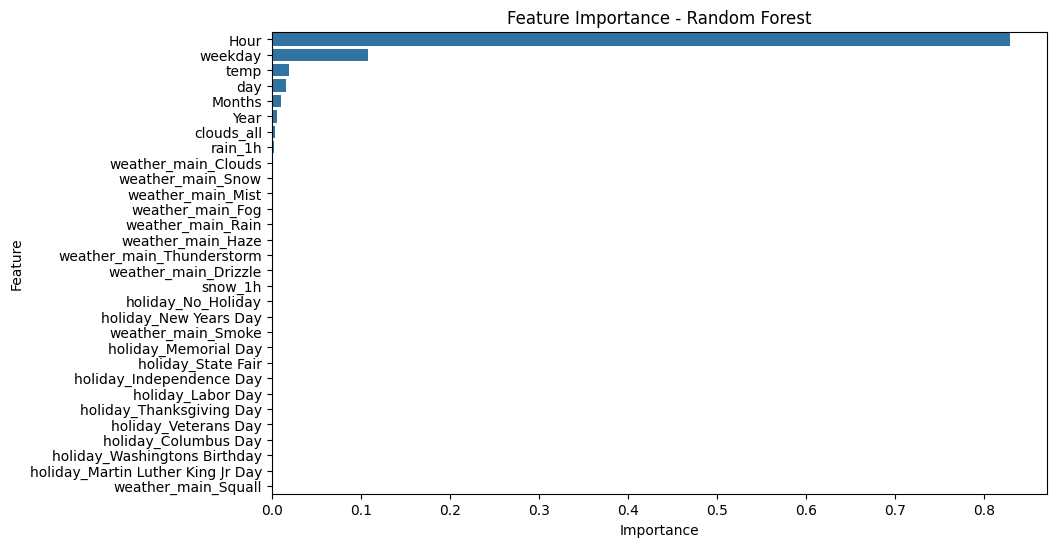

In [129]:
plt.figure(figsize = (10,6))
sns.barplot(y = 'Feature', x = 'Importance', data = importance_df)
plt.title('Feature Importance - Random Forest')
plt.show()

In [130]:
Evaluation = pd.DataFrame({'model':['Linear Regression', 'Random Forest', 'Random Forest tuned'], 'R2':[metrics.r2_score(y_test, y_pred_lr),metrics.r2_score(y_test, y_pred_rf),metrics.r2_score(y_test, y_pred_best)],'RMSE':[metrics.mean_squared_error(y_test,y_pred_lr),metrics.mean_squared_error(y_test,y_pred_rf),metrics.mean_squared_error(y_test,y_pred_best)]})
Evaluation

,model,R2,RMSE
0,Linear Regression,-1.462080,9.743566e+06
1,Random Forest,0.961780,1.512533e+05
2,Random Forest tuned,0.964733,1.395685e+05


In [131]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
import joblib

numeric_cols = ['temp','rain_1h','snow_1h','clouds_all','Hour','Year','Months','day','weekday']
categorical_cols = ['holiday','weather_main']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', best_rf)   # best model directly
])

pipeline.fit(df[numeric_cols + categorical_cols], df['traffic_volume'])

joblib.dump(pipeline, "traffic_pipeline.pkl", compress=3)

print("Pipeline saved successfully")


Pipeline saved successfully
